## Feature Engineering

### I will be doing Data processing and feature engineering in this notebook. I will be using the PSP_Jan_Feb_2019.xlsx dataset from which I will derive new features, using the additional information provided.

In [2]:
import numpy as np
import pandas as pd
#from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset as excel file    

df = pd.read_excel('PSP_Jan_Feb_2019.xlsx', index_col=0)
#df = pd.read_csv('use_case_1.csv')
df.head()

,tmsp,country,amount,success,PSP,3D_secured,card
0,2019-01-01 00:01:11,Germany,89,0,UK_Card,0,Visa
1,2019-01-01 00:01:17,Germany,89,1,UK_Card,0,Visa
2,2019-01-01 00:02:49,Germany,238,0,UK_Card,1,Diners
3,2019-01-01 00:03:13,Germany,238,1,UK_Card,1,Diners
4,2019-01-01 00:04:33,Austria,124,0,Simplecard,0,Diners


In [4]:
# Convert 'tmsp' to datetime
df['tmsp'] = pd.to_datetime(df['tmsp'],format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by tmsp to make it easier to find repeated transactions
df.sort_values(by='tmsp', inplace=True)

# Create a new column to store the attempt number
df['attempt_number'] = 1
for i in range(1, len(df)):
    if (df.loc[i, 'amount'] == df.loc[i-1, 'amount']) and \
       (df.loc[i, 'country'] == df.loc[i-1, 'country']) and \
       (df.loc[i, 'card'] == df.loc[i-1, 'card']) and \
       ((df.loc[i, 'tmsp'] - df.loc[i-1, 'tmsp']).total_seconds() < 60):
        df.loc[i, 'attempt_number'] = df.loc[i-1, 'attempt_number'] + 1



# Create a new column to store the count of repeated transactions for each PSP
df['repeated_transactions'] = 0

for i in range(1, len(df)):
    if (df.loc[i, 'tmsp'] - df.loc[i - 1, 'tmsp']).total_seconds() <= 60 \
            and df.loc[i, 'amount'] == df.loc[i - 1, 'amount'] \
            and df.loc[i, "country"] == df.loc[i - 1, "country"]:
        df.loc[i, 'repeated_transactions'] = df.loc[i - 1, 'repeated_transactions'] + 1

# Group by PSP and sum the counts of repeated transactions
result = df.groupby('PSP')['repeated_transactions'].sum()

In [5]:
data = df.copy()

In [6]:
# Check for missing values
print(data.isnull().sum())

tmsp                     0
country                  0
amount                   0
success                  0
PSP                      0
3D_secured               0
card                     0
attempt_number           0
repeated_transactions    0
dtype: int64


### I. Feature Engineering

In [7]:
# Define the transaction fee structure
fee_structure = {
    'UK_Card': {'success': 3, 'failure': 1},
    'Simplecard': {'success': 1, 'failure': 0.5},
    'Moneycard': {'success': 5, 'failure': 2},
    'Goldcard': {'success': 10, 'failure': 5}
}

# # Add transaction fee columns
# data['transaction_fee_success'] = data.apply(lambda row: fee_structure.get(row['PSP'], {'success': 0})['success'] if row['success'] == 1 else 0, axis=1)
# data['transaction_fee_failure'] = data.apply(lambda row: fee_structure.get(row['PSP'], {'failure': 0})['failure'] if row['success'] == 0 else 0, axis=1)

# Add total amount column
#data['total_amount'] = data['amount'] + data.apply(lambda row: row['transaction_fee_success'] if row['success'] == 1 else row['transaction_fee_failure'], axis=1)

# Identify repeated payment attempts

# Create additional features
data['is_first_attempt'] = (data.groupby((data['amount'] != data['amount'].shift()).cumsum()).cumcount() == 0) & \
                           (data.groupby(['amount', 'country']).shift(-1)['tmsp'] - data['tmsp']).lt(pd.Timedelta(minutes=1)).fillna(True)
#data['num_previous_attempts'] = data['attempt_number'] - 1
data['is_first_attempt'] = data['is_first_attempt'].astype(int)

# Define the function to calculate the total fee
# def calculate_total_fee(row):
#     psp = row['PSP']
#     success_status = row['success']
#     attempt_number = row['repeated_transactions']
    
#     if success_status:
#         # If transaction succeeded, calculate total fee based on failure fee for 1st attempt and success fee for subsequent attempts
#         total_fee = fee_structure[psp]['failure'] + fee_structure[psp]['success'] * (attempt_number - 1)
#     else:
#         # If transaction failed, use failure fee
#         total_fee = fee_structure[psp]['failure']
    
#     return total_fee
# # Apply the function to create the 'total_fee' column
# data['total_fee'] = df.apply(calculate_total_fee, axis=1)
# Calculate the total fees for each row based on success and repeated transactions
data['total_fees'] = data.apply(lambda row: fee_structure[row['PSP']]['success'] * row['success'] +
                                        fee_structure[row['PSP']]['failure'] * max(row['repeated_transactions'], 1),
                            axis=1)

# Display the modified dataset
data.head(15)

,tmsp,country,amount,success,PSP,3D_secured,card,attempt_number,repeated_transactions,is_first_attempt,total_fees
0,2019-01-01 00:01:11,Germany,89,0,UK_Card,0,Visa,1,0,1,1.0
1,2019-01-01 00:01:17,Germany,89,1,UK_Card,0,Visa,2,1,0,4.0
2,2019-01-01 00:02:49,Germany,238,0,UK_Card,1,Diners,1,0,1,1.0
3,2019-01-01 00:03:13,Germany,238,1,UK_Card,1,Diners,2,1,0,4.0
4,2019-01-01 00:04:33,Austria,124,0,Simplecard,0,Diners,1,0,0,0.5
5,2019-01-01 00:06:41,Switzerland,282,0,UK_Card,0,Master,1,0,1,1.0
6,2019-01-01 00:07:19,Switzerland,282,0,Simplecard,0,Master,2,1,0,0.5
7,2019-01-01 00:08:46,Germany,117,1,UK_Card,0,Master,1,0,0,4.0
8,2019-01-01 00:09:56,Switzerland,174,0,Simplecard,0,Visa,1,0,1,0.5
9,2019-01-01 00:10:49,Switzerland,174,0,Simplecard,0,Visa,2,1,0,0.5


In [8]:

# Create fetaures for time since last transaction
data['time_since_last_transaction'] = data.groupby(['amount', 'country', 'PSP'])['tmsp'].diff()

# # Create a binary feature indicating repeated attempts within one minute
data['is_repeat_attempt'] = (data['time_since_last_transaction'] <= pd.Timedelta('1 minute')).astype(int)
#data['is_repeat_attempt'] = (data['time_since_last_transaction'] <= pd.to_timedelta('1 minute')).astype(int)

# Aggregate transactions to count attempts within one minute
data['attempts_within_one_minute'] = data.groupby(['amount', 'country', 'tmsp'])['is_repeat_attempt'].transform('sum')
# Optionally, you can convert the time difference back to seconds for consistency
data['time_since_last_attempt_seconds'] = data['time_since_last_transaction'].dt.total_seconds()
data.drop('time_since_last_transaction', axis=1, inplace=True)

In [9]:
# Impute NaN values with 0
data.fillna(0, inplace=True)

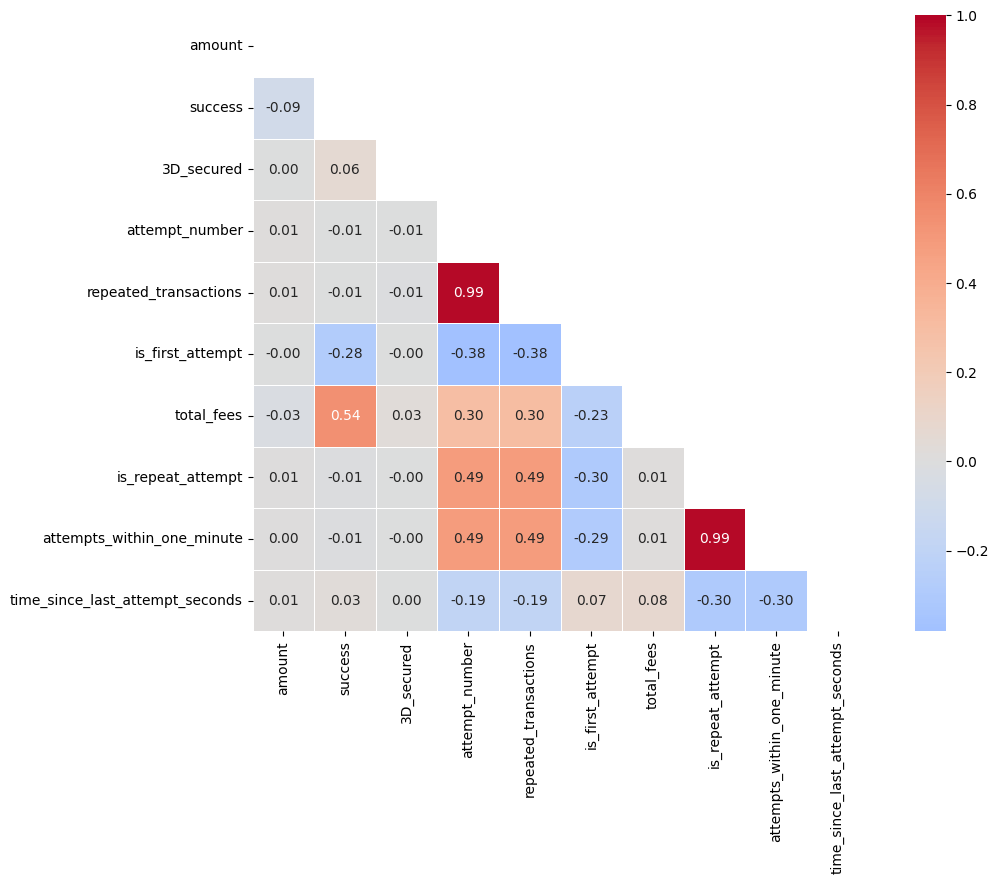

In [10]:
# Plot correlation matrix
# Create a mask for the upper triangle
correlation_matrix = data.corr(numeric_only=True)
#corr_matrix = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', vmax=1, center=0, fmt='.2f',
            square=True, annot=True, linewidths=.5)

plt.show()

In [11]:
data.columns

Index(['tmsp', 'country', 'amount', 'success', 'PSP', '3D_secured', 'card',
       'attempt_number', 'repeated_transactions', 'is_first_attempt',
       'total_fees', 'is_repeat_attempt', 'attempts_within_one_minute',
       'time_since_last_attempt_seconds'],
      dtype='object')

### Since _is_first_attempt_ and _attempts_within_one_minute_ refer to almost the same thing and hence have shown to be highly correlated, I drop one of them (*is_repeat_attempt*). Same thing with _amount_ and _total_amount, and _num_previous_attempts_ and _attempt_number_

In [12]:
# Drop columns that are not useful
data.drop(['is_repeat_attempt', 'attempt_number'], axis=1, inplace=True)

In [ ]:
# Check if each repeated transaction was recorded individually
repeated_transactions = data[data['repeated_transactions'] > 1].groupby(['amount', 'country', 'card'])
for group_name, group in repeated_transactions:
    if len(group) != group['repeated_transactions'].max():
        print(f"Warning: Not all attempts were recorded for transaction with amount {group_name[0]}, country {group_name[1]}, and card {group_name[2]}")

In [14]:
# Encode categorical variables using one-hot encoding
#data_encoded = pd.get_dummies(data[['country', 'PSP', 'card']], drop_first=True)
data_encoded = pd.get_dummies(data[['country', 'card']], drop_first=True)
# Drop the original timestamp and categorical columns
#data.drop(['tmsp', 'country', 'PSP', 'card'], axis=1, inplace=True)
data_encoded = data_encoded.astype(int)
data_encoded.head()

,country_Germany,country_Switzerland,card_Master,card_Visa
0,1,0,0,1
1,1,0,0,1
2,1,0,0,0
3,1,0,0,0
4,0,0,0,0


In [15]:
# Extract day, month, and year from the 'tmsp' column

data['hour'] = data['tmsp'].dt.hour
data['day'] = data['tmsp'].dt.day
data['month'] = data['tmsp'].dt.month
data['day_of_week'] = data['tmsp'].dt.dayofweek

# Concatenate the DataFrames along columns (axis=1)
data = pd.concat([data, data_encoded], axis=1)
# Drop the original timestamp and categorical columns
#data.drop(['tmsp', 'country', 'PSP', 'card'], axis=1, inplace=True)
#data.drop(['tmsp', 'country',  'card'], axis=1, inplace=True)
data.drop(['country',  'card'], axis=1, inplace=True)

data.head()

,tmsp,amount,success,PSP,3D_secured,repeated_transactions,is_first_attempt,total_fees,attempts_within_one_minute,time_since_last_attempt_seconds,hour,day,month,day_of_week,country_Germany,country_Switzerland,card_Master,card_Visa
0,2019-01-01 00:01:11,89,0,UK_Card,0,0,1,1.0,0,0.0,0,1,1,1,1,0,0,1
1,2019-01-01 00:01:17,89,1,UK_Card,0,1,0,4.0,1,6.0,0,1,1,1,1,0,0,1
2,2019-01-01 00:02:49,238,0,UK_Card,1,0,1,1.0,0,0.0,0,1,1,1,1,0,0,0
3,2019-01-01 00:03:13,238,1,UK_Card,1,1,0,4.0,1,24.0,0,1,1,1,1,0,0,0
4,2019-01-01 00:04:33,124,0,Simplecard,0,0,0,0.5,0,0.0,0,1,1,1,0,0,0,0


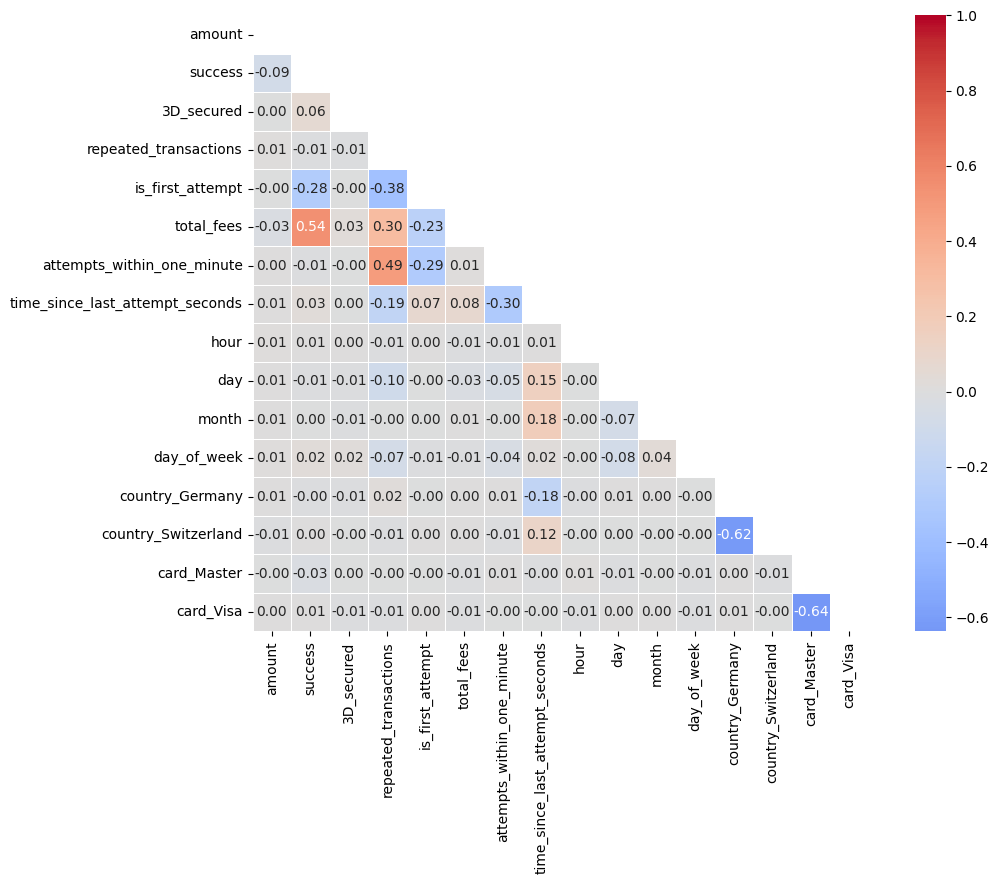

In [16]:
# Plot correlation matrix
# Create a mask for the upper triangle
correlation_matrix = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', vmax=1, center=0, fmt='.2f',
            square=True, annot=True, linewidths=.5)

plt.show()

The correlation matrix shows that most of the features correlate weakly with the target variable. Only the `tota_fees` is strongly correlated with the target variable. We see that `total_fees` correlates positively somewhat with `repeated_transactions` and `is_first_attempt`

<Axes: xlabel='amount', ylabel='total_fees'>

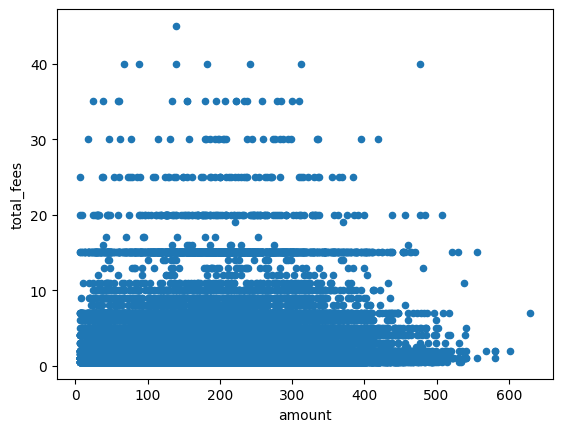

In [17]:
# Plot scatter plot of amount and total_fees
data.plot.scatter(x='amount', y='total_fees')


The above plot shows that the relationship between amount and total fees is not linear. One thing that can be observed is that there is a significant difference in the average total fees between successful and failed transactions. Some higher total fees are associated with lower amounts.

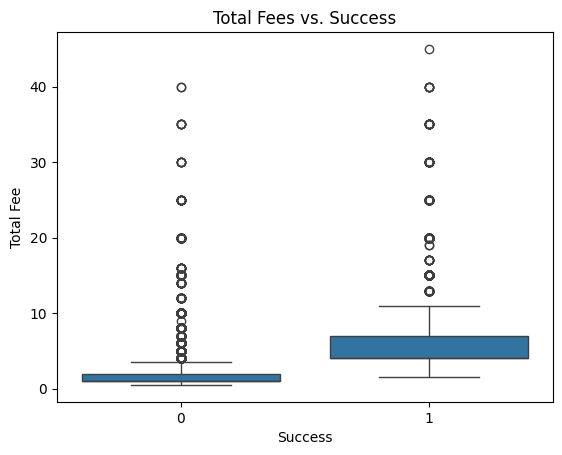

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame containing 'total_fee' and 'success' columns
sns.boxplot(x='success', y='total_fees', data=data)
plt.xlabel('Success')
plt.ylabel('Total Fee')
plt.title('Total Fees vs. Success')
plt.show()


The above plot shows that there is a significant difference in the average total fees between successful and failed transactions.

In [19]:
from scipy.stats import ttest_ind

# Assuming 'data' is your DataFrame containing 'total_fee' and 'success' columns
success_total_fee = data[data['success'] == 1]['total_fees']
failure_total_fee = data[data['success'] == 0]['total_fees']

# Perform t-test
t_stat, p_value = ttest_ind(success_total_fee, failure_total_fee)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 144.83422703581238
P-value: 0.0


The p-value is less than 0.05, so we reject the null hypothesis. We can conclude that there is a significant difference in the average total fees between successful and failed transactions.

In [21]:
# Change day of week to day names
day_of_week = data['day_of_week'].map({0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'})

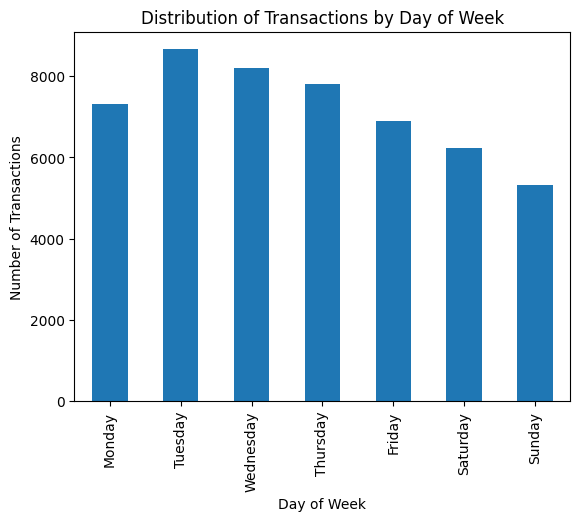

In [22]:
# Create bar chart for days of week and total_amount. Don't rank the days of the week

import matplotlib.pyplot as plt

# Set the order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Get the counts for each day
day_counts = data['day_of_week'].map({0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}).value_counts().loc[day_order]

# Plot the bar chart
day_counts.plot(kind='bar')

# Customize plot if needed
plt.title('Distribution of Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')

# Show the plot
plt.show()




#### Here, we see that the volume of transactions is significantly higher between Tuesday and Thursday. This is likely due to the holidays. And it steadily decreases from Thursday to Sunday. This could be due to the fact that customers do not want to transact close to the weekend as should there be any problems, they may not get the neccessary service.

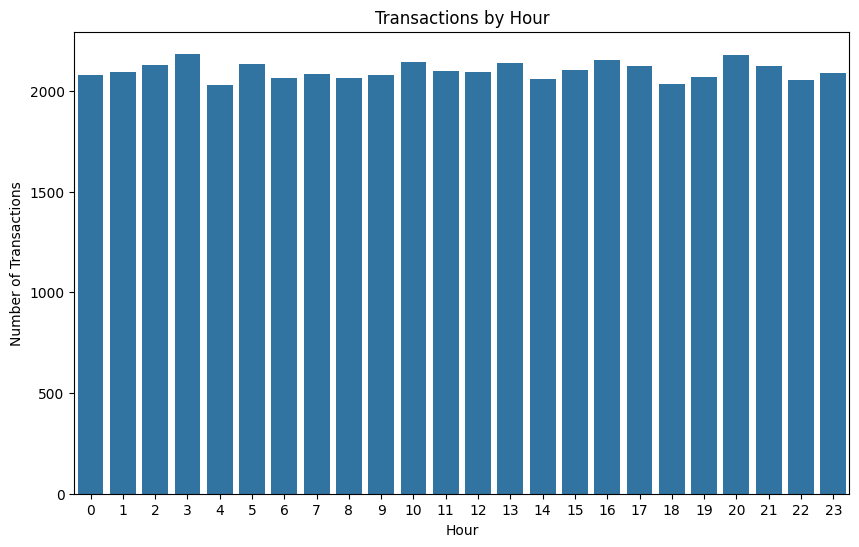

In [23]:
# Plot transactions by hour of the day
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='hour')
plt.title('Transactions by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.show()

The plot shows that there is no so much difference on the volume of transaction over the day

In [24]:
data_copy = data.copy()

### Encoding time-related features using sine and cosine

In [25]:

data_copy['hour_sin'] = np.sin(2 * np.pi * data_copy['hour'] / 24)
data_copy['hour_cos'] = np.cos(2 * np.pi * data_copy['hour'] / 24)

# If month == 2, then divide by 29, else divide by 31
#df['day'] = df['day'].apply(lambda x: x if x != 2 else 29 if df['month'] == 2 else 31)
#For 'day', use conditional statements to handle varying number of days in a month
data_copy['day_sin'] = np.sin(2 * np.pi * data_copy['day'] / np.where(data_copy['month'] == 2, 28, 31))
data_copy['day_cos'] = np.cos(2 * np.pi * data_copy['day'] / np.where(data_copy['month'] == 2, 28, 31))

data_copy['month_sin'] = np.sin(2 * np.pi * data_copy['month'] / 12)
data_copy['month_cos'] = np.cos(2 * np.pi * data_copy['month'] / 12)

# Calculate the angle for each day of the week
data_copy['day_of_week_sin'] = np.sin(2 * np.pi * data_copy['day_of_week'] / 7)
data_copy['day_of_week_cos'] = np.cos(2 * np.pi * data_copy['day_of_week'] / 7)

In [26]:
# Send the target column to the end
data_copy = data_copy[[c for c in data_copy.columns if c != 'success'] + ['success']]

data_copy.columns

Index(['tmsp', 'amount', 'PSP', '3D_secured', 'repeated_transactions',
       'is_first_attempt', 'total_fees', 'attempts_within_one_minute',
       'time_since_last_attempt_seconds', 'hour', 'day', 'month',
       'day_of_week', 'country_Germany', 'country_Switzerland', 'card_Master',
       'card_Visa', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'success'],
      dtype='object')

In [27]:
data_copy = data_copy.drop(['month', 'day_of_week'], axis=1)

In [28]:
# Save a copy of the data as a CSV file
data_copy.to_csv('processed_data.csv', index=False)